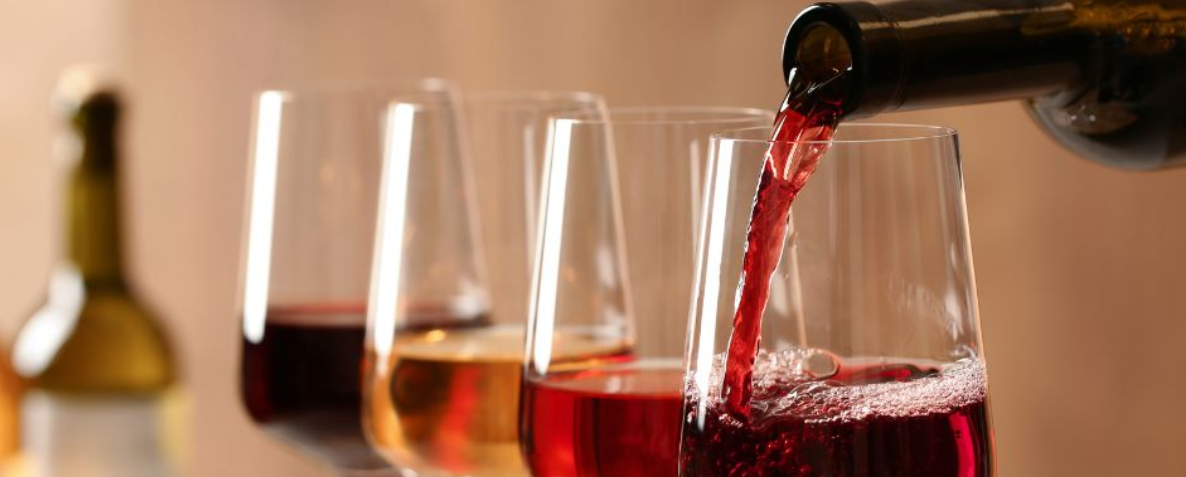

Al igual que en el notebook 10_01_ML_KNN_CLASIFICADOR_PCA.ipynb, el objetivo de clasificación a partir del dataset de vinos de scikit-learn es predecir la variedad de vino (o clase) basándose en las características químicas de cada muestra de vino.

**Clases (etiquetas):** Existen tres tipos de vinos en el conjunto de datos, representados como:

- Clase 0: Vino tipo 1
- Clase 1: Vino tipo 2
- Clase 2: Vino tipo 3

**Características (atributos):** Hay 13 características que describen la composición química de cada vino. Estas características incluyen:

- Alcohol
- Ácido málico
- Cenizas
- Alcalinidad de las cenizas
- Magnesio
- Fenoles totales
- Flavonoides
- Fenoles no flavonoides
- Proantocianinas
- Intensidad del color
- Tono
- OD280/OD315 (proporción de absorción de luz)
- Prolina (un aminoácido)

Para implementar el algoritmo **Learning Vector Quantization (LVQ**) usando MiniSom con el dataset de vinos, es necesario seguir varios pasos, que incluyen la preparación de los datos, la configuración del modelo LVQ con MiniSom, el entrenamiento, y la evaluación de los resultados utilizando métricas adecuadas como la precisión, recall, F1 score, etc.

### **Paso 1:** Importar las bibliotecas necesarias

In [ ]:
!pip install minisom

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from minisom import MiniSom
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### **Paso 2:** Cargar y preparar el dataset de vinos

In [ ]:
# Cargar el dataset de vinos
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


### **Paso 3:** Configurar y entrenar el LVQ con MiniSom

In [ ]:
# Definir el tamaño de la cuadrícula para el SOM
som_shape = (7, 7)  # Tamaño de la cuadrícula del SOM (puede ajustarse)

# Inicializar MiniSom (Learning Vector Quantization basado en SOM)
som = MiniSom(x=som_shape[0], y=som_shape[1], input_len=X_train.shape[1], sigma=0.5, learning_rate=0.5)

# Entrenar el SOM con los datos de entrenamiento
som.random_weights_init(X_train)
som.train_random(X_train, num_iteration=1000)


### **Paso 4:** Asignar etiquetas a las neuronas

Para usar LVQ, debemos asignar etiquetas a las neuronas del SOM en función de las muestras más cercanas:

In [ ]:
# Asignar etiquetas a las neuronas del SOM
def assign_labels(som, X_train, y_train):
    win_map = som.win_map(X_train)
    labels_map = np.zeros((som_shape[0], som_shape[1], len(np.unique(y_train))))

    # Asignar etiquetas a cada nodo ganador
    for position, values in win_map.items():
        labels, counts = np.unique(y_train[np.isin(X_train, values).all(axis=1)], return_counts=True)
        labels_map[position][labels[np.argmax(counts)]] = 1  # Etiqueta mayoritaria

    return labels_map

labels_map = assign_labels(som, X_train, y_train)


### **Paso 5:** Clasificar datos de prueba y calcular métricas

In [ ]:
# Función para predecir la clase de una nueva muestra
def predict(som, labels_map, X):
    predictions = []
    for x in X:
        winner = som.winner(x)
        predictions.append(np.argmax(labels_map[winner]))
    return predictions

# Predecir las clases para los datos de prueba
y_pred = predict(som, labels_map, X_test)

# Evaluar el rendimiento con métricas de clasificación
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=wine.target_names))


Accuracy: 0.9259259259259259
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        19
     class_1       1.00      0.81      0.89        21
     class_2       0.82      1.00      0.90        14

    accuracy                           0.93        54
   macro avg       0.92      0.94      0.92        54
weighted avg       0.94      0.93      0.92        54



Para visualizar los prototipos del LVQ en un espacio reducido, como 2D, se puede usar el Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de los datos y visualizar los prototipos en un gráfico.

Este proceso implica las siguientes etapas:

1.   Obtener los prototipos (vectores de pesos) del SOM.
2.   Aplicar PCA para reducir la dimensionalidad de los prototipos.
3.   Visualizar los prototipos en un gráfico 2D.


### **1. Obtener los prototipos (vectores de pesos) del SOM.**

Para obtener los prototipos, podemos usar los pesos de las neuronas en el SOM. Estos representan los prototipos aprendidos por el modelo.

In [ ]:
# Obtener los pesos (prototipos) del SOM
weights = som.get_weights()

### **2. Aplicar PCA para reducir la dimensionalidad de los prototipos**

In [ ]:
# Aplanar los pesos para aplicarle PCA
weights_flattened = weights.reshape(-1, weights.shape[2])

# Aplicar PCA para reducir a 2D
pca = PCA(n_components=2)
weights_pca = pca.fit_transform(weights_flattened)


### **3. Visualizar los prototipos en un gráfico 2D**

Ahora que tenemos los prototipos en 2D, podemos visualizarlos con matplotlib.

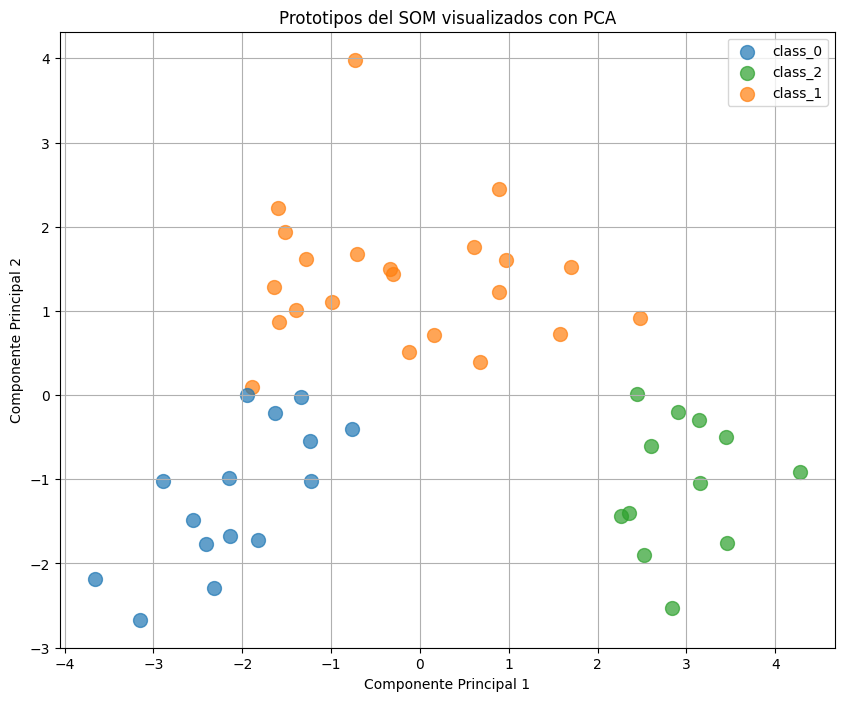

In [ ]:
# Crear gráfico de los prototipos en 2D
plt.figure(figsize=(10, 8))

# Definir un cmap para colores de clases
cmap = plt.get_cmap('tab10')

# Crear una lista para manejar las leyendas
handles = []
labels = []

# Recorrer cada posición en la cuadrícula del SOM
for i in range(som_shape[0]):
    for j in range(som_shape[1]):
        # Obtener la posición en 2D y la clase mayoritaria
        pos_2d = weights_pca[i * som_shape[1] + j]
        major_class = np.argmax(labels_map[i, j])

        # Añadir el punto al gráfico
        handle = plt.scatter(pos_2d[0], pos_2d[1], c=[cmap(major_class)], s=100, alpha=0.7)

        # Añadir el handle y la etiqueta para la leyenda
        if wine.target_names[major_class] not in labels:
            handles.append(handle)
            labels.append(wine.target_names[major_class])

# Añadir la leyenda con las tres clases
plt.legend(handles, labels)

plt.title('Prototipos del SOM visualizados con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()